In [21]:
# CIL imports
from cil.framework import ImageData, ImageGeometry
from cil.framework import AcquisitionGeometry, AcquisitionData

from cil.plugins.astra.operators import ProjectionOperator

from cil.utilities.display import show2D

# External imports
from phantominator import shepp_logan
import numpy as np
from scipy.linalg import svd
import matplotlib.pyplot as plt

from cil.utilities.display import show_geometry

from cil.plugins.astra.processors import FBP

In [22]:
# number of pixels and angles
n_pixels = 100
n_angles = 50

# other input
cmap = 'rainbow'
device = 'cpu'

In [23]:
# Angles
angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)


# Setup acquisition geometry
# with sufficient number of projections
ag = AcquisitionGeometry.create_Cone2D(source_position=[0,-1], detector_position= [0,1])\
                            .set_angles(angles)\
                            .set_panel(n_pixels, pixel_size=1/n_pixels)

# Setup image geometry
ig = ImageGeometry(voxel_num_x=n_pixels, 
                   voxel_num_y=n_pixels, 
                   voxel_size_x=1/n_pixels, 
                   voxel_size_y=1/n_pixels)

# Get phantom
phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)
size_phantom = phantom.shape

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


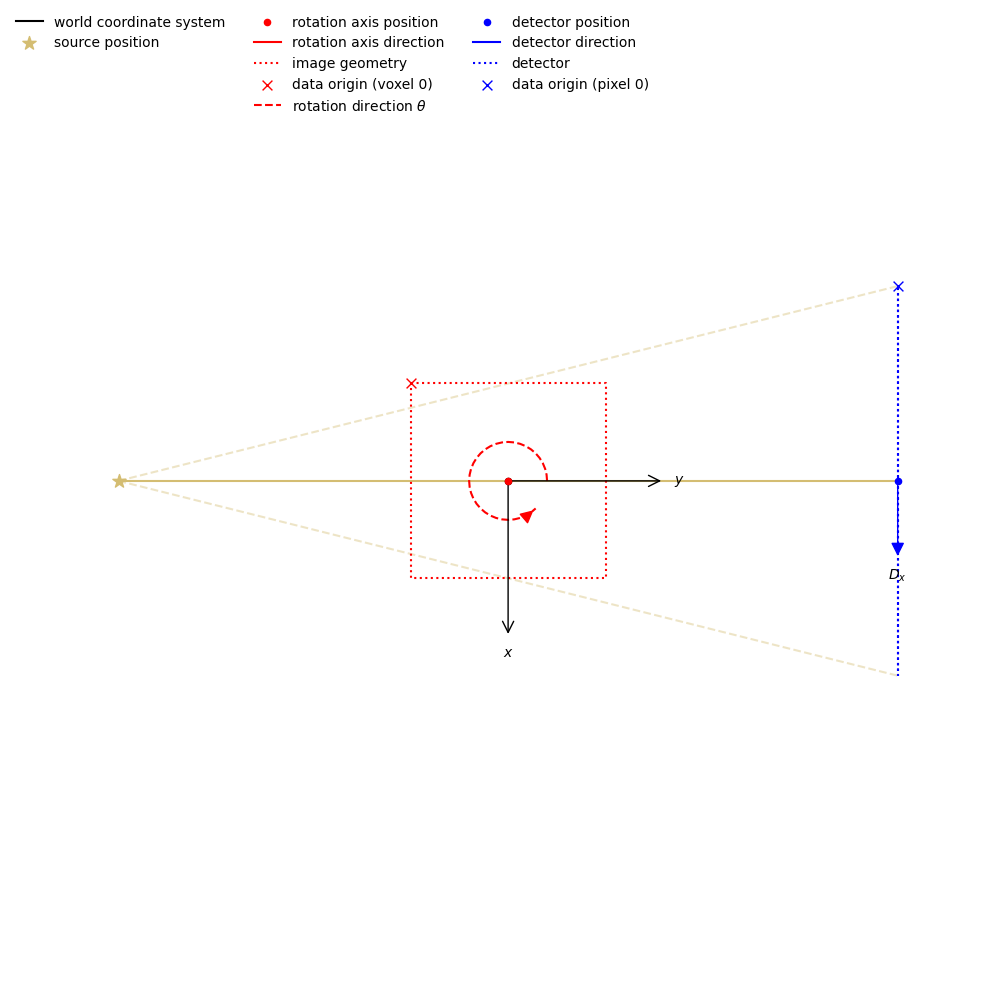

In [24]:
show_geometry(ag)

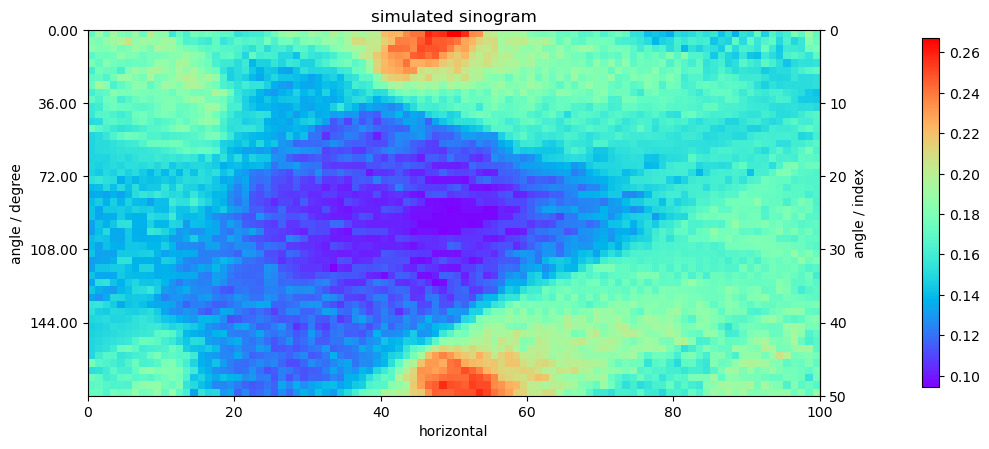

In [25]:
# Create projection operator using Astra-Toolbox.
A = ProjectionOperator(ig, ag, device)

# Create an acquisition data (numerically)
sino = A.direct(phantom)

# Visualise data
show2D(sino, 'simulated sinogram', cmap=cmap, size=(10,10), origin='upper-left')

In [26]:
# configure FBP
fbp = FBP(ig, ag, device)

# reconstruct
recon = fbp(sino)

NotImplementedError: Cannot process cone-beam data without a GPU